# Residual diagnostics (validation)

**Residual** for each row:

$$e_i = y_i - \hat{y}_i$$

where $y_i$ is the **actual** return and $\hat{y}_i$ is the **predicted** return for the same `(date, asset)` row.

This notebook builds validation predictions and plots **residuals vs time** (per asset) and **residuals vs fitted**.

In [14]:
import sys
from pathlib import Path

# Repo layout: notebooks/ is next to src/
ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import replace

from portfolio_optim.config import BaselineConfig
from portfolio_optim.ml.dataset import build_supervised_dataset
from portfolio_optim.ml.models import fit_return_predictor
from portfolio_optim.experiments.run_baseline import _date_splits

## 1. Load returns and fit (same protocol as `run_experiment`)

Switch **`USE_SYNTHETIC`** / **`LOCAL_DIR`** to match how you run locally.

In [15]:
USE_SYNTHETIC = True
LOCAL_DIR = Path(r"C:\path\to\stooq\folder")  # used if USE_SYNTHETIC is False

cfg = replace(BaselineConfig(), lookback=20)

if USE_SYNTHETIC:
    from portfolio_optim.data.generate import simulate_linear_factor_returns
    rng = np.random.default_rng(cfg.random_seed)
    returns = simulate_linear_factor_returns(cfg.n_assets, cfg.n_periods, rng=rng)
else:
    from portfolio_optim.data.local_panel import download_returns_from_stooq_local_dir
    returns = download_returns_from_stooq_local_dir(LOCAL_DIR, glob_pattern="*.txt")

train_idx, val_idx, test_idx = _date_splits(returns, cfg)
X, y, mindex = build_supervised_dataset(returns, cfg.lookback)

dates_all = mindex.get_level_values("date")
train_mask = np.isin(dates_all, train_idx)
val_mask = np.isin(dates_all, val_idx)

model = fit_return_predictor(X[train_mask], y[train_mask], cfg.ridge_alpha)
pred = model.predict(X[val_mask])
yv = y[val_mask]

residual = yv - pred  # shape matches pred and yv
print("val rows:", residual.shape[0], "| features:", X.shape[1])

val rows: 3000 | features: 20


## 2. Long table for plotting

One row per `(date, asset)` in **validation**.

In [16]:
val_df = pd.DataFrame(
    {
        "date": dates_all[val_mask],
        "asset": mindex.get_level_values("asset")[val_mask],
        "y_actual": yv,
        "y_pred": pred,
        "residual": residual,
    }
).sort_values(["asset", "date"])

val_df.head()

,date,asset,y_actual,y_pred,residual
0,2001-02-26,A00,-0.035003,0.000171,-0.035174
30,2001-02-27,A00,-0.007714,-0.000040,-0.007674
60,2001-02-28,A00,-0.045391,-0.000619,-0.044771
90,2001-03-01,A00,-0.008627,0.000090,-0.008716
120,2001-03-02,A00,-0.000310,-0.000317,0.000008


## 2b. Baseline RMSE (same validation rows)

Compare your model to **trivial** predictors on **identical** `yv`:

| Baseline | Meaning |
|----------|--------|
| **zero** | always predict `0` |
| **train_mean** | always predict the train-set mean of `y` |
| **persistence** | predict yesterday’s return = last lag in `X` (`X[val_mask, -1]`) |

**"Good"** ≈ model RMSE **below** these (especially zero / mean).

In [17]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))


y_train = y[train_mask]
X_val = X[val_mask]

pred_zero = np.zeros_like(yv, dtype=float)
pred_mean = np.full_like(yv, y_train.mean(), dtype=float)
pred_persist = X_val[:, -1].astype(float)  # last lag ≈ most recent daily return before label

rows = [
    ("zero", pred_zero),
    ("train_mean", pred_mean),
    ("persistence (last lag)", pred_persist),
    ("ridge model", pred),
]
print("Validation RMSE (lower is better):\n")
for name, p in rows:
    print(f"  {name:28s}  {rmse(yv, p):.6f}")

Validation RMSE (lower is better):

  zero                          0.020858
  train_mean                    0.020857
  persistence (last lag)        0.029338
  ridge model                   0.020865


In [31]:
rows_out = []
for asset in val_df["asset"].unique():
    m = val_df["asset"].values == asset
    ya = yv[m]
    rows_out.append({
        "asset": asset,
        "zero": rmse(ya, pred_zero[m]),
        "train_mean": rmse(ya, pred_mean[m]),
        "persistence": rmse(ya, pred_persist[m]),
        "ridge": rmse(ya, pred[m]),
    })
per_asset = pd.DataFrame(rows_out).sort_values("asset")
# per_asset

ValueError: x and y must have same first dimension, but have shapes (100,) and (1,)

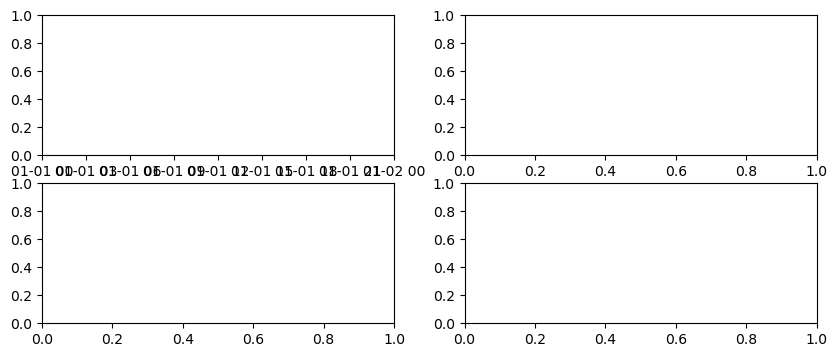

In [28]:
# Residuals vs time baseline
fig, axs = plt.subplots(2,2, figsize=(10, 4))

for i in range(2):
    for j in range(2):
        axs[i][j].axhline(0.0, color="k", lw=0.8, alpha=0.5)
        axs[i][j].plot(g["date"], rmse(yv, rows[i*2 + j][1]), marker=".", linestyle="-", alpha=0.8)
        axs[i][j].set_title(f"Residual vs time (validation) — {rows[i*2 + j][0]}")
        axs.set_xlabel("date")
        axs.set_ylabel(r"residual $y - \hat{y}$")


## 3. Residuals vs time — **one asset**

Pick a column name from `returns.columns` (e.g. first ticker).

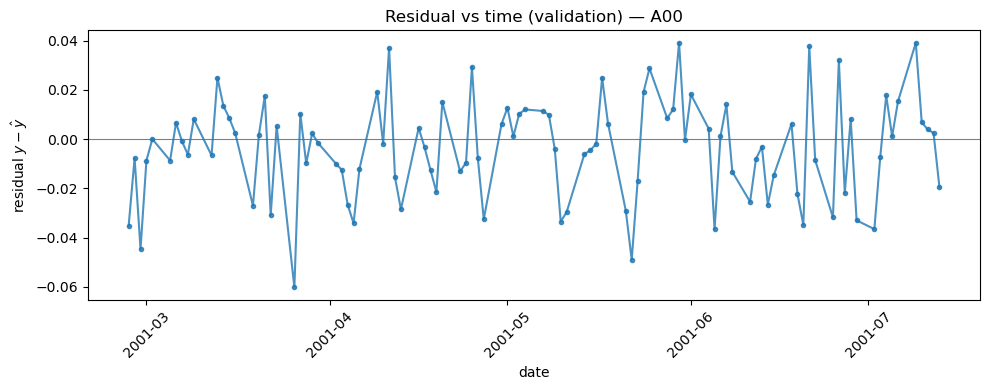

In [ ]:
sym = val_df["asset"].iloc[0]
g = val_df[val_df["asset"] == sym]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
ax.plot(g["date"], g["residual"], marker=".", linestyle="-", alpha=0.8)
ax.set_title(f"Residual vs time (validation) — {sym}")
ax.set_xlabel("date")
ax.set_ylabel(r"residual $y - \hat{y}$")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Residuals vs time — **small multiples** (optional)

Use a subset of assets if the universe is large.

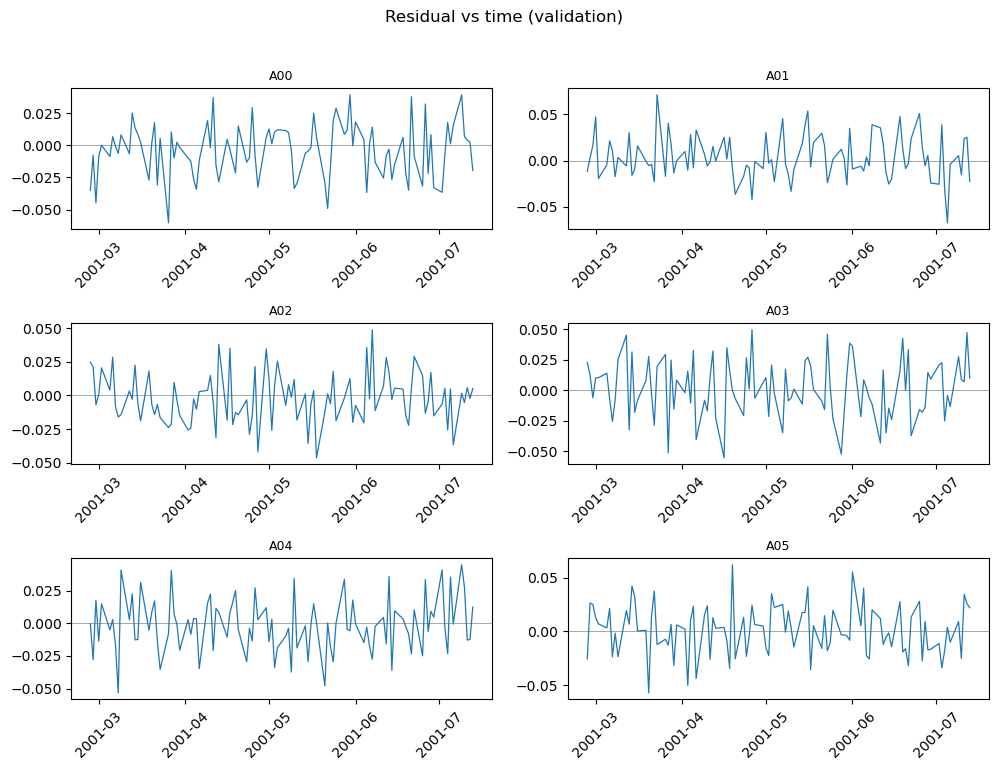

In [19]:
assets = list(val_df["asset"].unique())[:6]
ncols = 2
nrows = int(np.ceil(len(assets) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.5 * nrows), sharex=False)
axes = np.atleast_1d(axes).ravel()

for i, sym in enumerate(assets):
    ax = axes[i]
    g = val_df[val_df["asset"] == sym]
    ax.axhline(0.0, color="k", lw=0.6, alpha=0.4)
    ax.plot(g["date"], g["residual"], lw=0.9)
    ax.set_title(sym, fontsize=9)
    ax.tick_params(axis="x", rotation=45)

for j in range(len(assets), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Residual vs time (validation)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Residual vs **fitted** (standard regression diagnostic)

x-axis: $\hat{y}$, y-axis: $y - \hat{y}$. Looks for fan shapes / curvature.

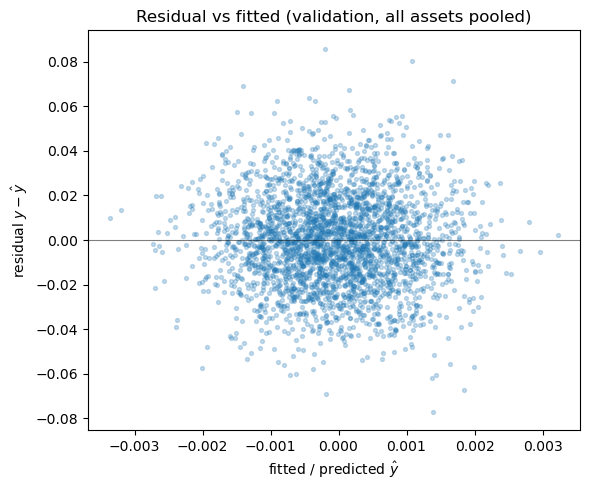

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
ax.scatter(pred, residual, s=8, alpha=0.25)
ax.set_xlabel(r"fitted / predicted $\hat{y}$")
ax.set_ylabel(r"residual $y - \hat{y}$")
ax.set_title("Residual vs fitted (validation, all assets pooled)")
plt.tight_layout()
plt.show()